In [13]:
# packed_cobble_field
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm
from scipy.spatial import cKDTree
import math
import os

In [ ]:
# ---------------- User parameters ----------------
Lx, Ly = 10.0, 2.0        # domain size (m)
dx_grid = 0.03           # grid spacing for initial seed of centers (m)
# D15, D50, D85 = 32.0, 40.0, 59.0   # input percentiles (units: mm or whichever; output uses same units)
D15, D50, D85 = 0.038, 0.059, 0.105   # input percentiles (units: m)
N_samples = 20000        # pool of diameters to sample from (we'll sample needed N from these)
packing_fraction_target = 0.65  # desired approximate area fraction of domain covered by cobbles (0..1)
max_iter = 500          # relaxation iterations
relaxation_rate = 0.8  # controls how strongly overlapped particles are pushed apart (0-1)
random_seed = 12345

In [5]:
# ---------------- Fit lognormal from percentiles (least squares in log-space) ----------------
p_vals = np.array([0.15, 0.5, 0.85])
z_vals = norm.ppf(p_vals)
lnD_vals = np.log([D15, D50, D85])
A = np.vstack([np.ones_like(z_vals), z_vals]).T
mu, sigma = np.linalg.lstsq(A, lnD_vals, rcond=None)[0]
dist = lognorm(s=sigma, scale=np.exp(mu))

print(f"Fitted lognormal mu={mu:.6f}, sigma={sigma:.6f}")

Fitted lognormal mu=-2.784727, sigma=0.490323


Using unit scale factor: 1.000000
Target number of cobbles ≈ 4341
Initial centers count: 4341
Iter 0, total overlap 236.254888, max disp 1.3995e-01
Iter 100, total overlap 38.645294, max disp 1.2595e-02
Iter 200, total overlap 26.288880, max disp 8.9148e-03
Iter 300, total overlap 19.441517, max disp 6.5801e-03
Iter 400, total overlap 14.829851, max disp 5.5647e-03
Iter 0, total overlap 11.537743, max disp 4.6446e-03
Iter 100, total overlap 9.160580, max disp 3.9499e-03
Iter 200, total overlap 7.327875, max disp 3.4187e-03
Final cobbles: 4341
Saved CSV: cobble_packing.csv
Saved NetCDF: cobble_packing.nc


Using unit scale factor: 1.000000
Target number of cobbles ≈ 4341
Initial centers count: 4341
Iter 0, total overlap 236.254888, max disp 1.3995e-01
Iter 100, total overlap 38.645294, max disp 1.2595e-02
Iter 200, total overlap 26.288880, max disp 8.9148e-03
Iter 300, total overlap 19.441517, max disp 6.5801e-03
Iter 400, total overlap 14.829851, max disp 5.5647e-03
Iter 0, total overlap 11.537743, max disp 4.6446e-03
Iter 100, total overlap 9.160580, max disp 3.9499e-03
Iter 200, total overlap 7.327875, max disp 3.4187e-03
Final cobbles: 4341
Saved CSV: cobble_packing.csv
Saved NetCDF: cobble_packing.nc


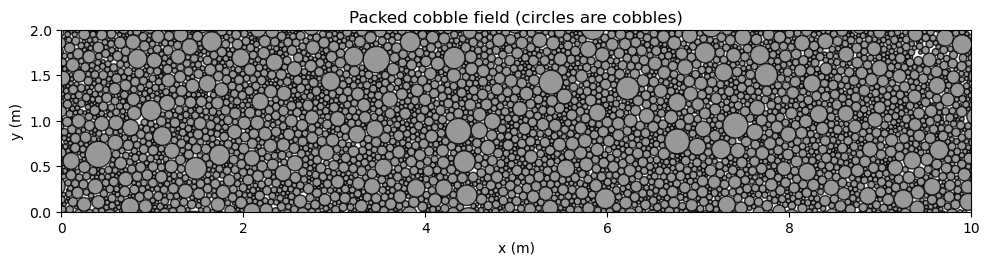

Saved PNG: cobble_packing.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the PDF of the fitted lognormal distribution
x = np.linspace(0.01, 0.2, 1000)  # range from 0.01 to 0.2 m
plt.figure(figsize=(8, 5))
plt.plot(x, dist.pdf(x), label='Fitted Lognormal PDF')
plt.xlabel('Diameter (m)')
plt.ylabel('Probability Density')
plt.title('Fitted Lognormal Distribution for Cobble Diameters')
plt.legend()
plt.grid(True)
plt.show()
# ---------------- Estimate number of cobbles to fill domain ----------------
area_domain = Lx * Ly
# diameters are in same units — ensure area calculation units consistent:
# convert diameters to meters if your D values are in mm; here I assume units already meters.
# If your D's are mm, convert: diam_m = diam_mm / 1000
# For now, check if D values are >>1. If D values were in mm (32..59), convert:
if D50 > 10:  # assume input in mm => convert to m
    print("Detected D values >10 -> assuming inputs in mm; converting diameters to meters for packing.")
    unit_scale = 1/1000.0
else:
    unit_scale = 1.0

print(f"Using unit scale factor: {unit_scale:.6f}")

# get mean area per cobble (use geometric mean)
mean_diameter = np.exp(mu) * unit_scale
mean_area = np.pi * (mean_diameter/2.0)**2
N_target = int((area_domain * packing_fraction_target) / mean_area)
N_target = max(10, N_target)
print(f"Target number of cobbles ≈ {N_target}")

# ---------------- Sample diameters ----------------
rng = np.random.default_rng(random_seed)
# sample more than needed then trim to target to keep variety
diam_samples = dist.rvs(size=N_samples, random_state=random_seed) * unit_scale
# clip to reasonable min/max to avoid extremely tiny or huge cobbles
diam_samples = np.clip(diam_samples, 0.005*unit_scale, min(Lx, Ly))  # at least 5 mm in m or scaled
diameters = rng.choice(diam_samples, size=N_target, replace=False)

# ---------------- Create dense initial grid of candidate centers ----------------
# We create a lattice of points with spacing small relative to smallest diameter to avoid large holes,
# then select first N_target points (or shuffle them) as initial centers.
seed_spacing = (np.min(diameters) * 0.6)  # smaller than smallest diameter to be dense
if seed_spacing < dx_grid * 0.5:
    seed_spacing = dx_grid * 0.5

xs = np.arange(seed_spacing/2, Lx, seed_spacing)
ys = np.arange(seed_spacing/2, Ly, seed_spacing)
xx, yy = np.meshgrid(xs, ys)
candidates = np.vstack([xx.ravel(), yy.ravel()]).T
rng.shuffle(candidates)
if candidates.shape[0] < N_target:
    # fallback: create regular grid spaced by min diameter*0.4
    spacing2 = max( min(diameters)*0.4, dx_grid*0.5 )
    xs = np.arange(spacing2/2, Lx, spacing2)
    ys = np.arange(spacing2/2, Ly, spacing2)
    xx, yy = np.meshgrid(xs, ys)
    candidates = np.vstack([xx.ravel(), yy.ravel()]).T

# choose the first N_target candidate centers as initial centers
centers = candidates[:N_target].astype(float)
# assign diameters to centers (shuffle diameters to randomize spatial distribution)
rng.shuffle(diameters)
# pair them one-to-one
R = diameters / 2.0  # radii in meters (since diameters converted above)
print("Initial centers count:", centers.shape[0])

# ---------------- Relaxation loop to remove overlaps ----------------
def remove_overlaps(centers, R, Lx, Ly, max_iter=500, relaxation_rate=0.5):
    N = centers.shape[0]
    for it in range(max_iter):
        tree = cKDTree(centers)
        # find neighbors within max possible overlap distance
        maxR = R.max()
        pairs = tree.query_pairs(r=2*maxR + 1e-12)  # pairs set
        if not pairs:
            # no close pairs (rare), exit early
            break
        overlaps = []
        total_overlap = 0.0
        disp = np.zeros_like(centers)
        for i,j in pairs:
            # vector from j to i
            vi = centers[i]
            vj = centers[j]
            rij = vi - vj
            dist = np.hypot(rij[0], rij[1])
            # allowed minimum distance:
            min_dist = R[i] + R[j]
            if dist < 1e-12:
                # coincident centers: small random push
                theta = rng.random() * 2*np.pi
                rij = np.array([np.cos(theta), np.sin(theta)]) * 1e-6
                dist = np.hypot(rij[0], rij[1])
            overlap = min_dist - dist
            if overlap > 1e-8:
                # compute displacement vector proportional to overlap
                direction = rij / dist
                # distribute displacement proportional to each radii (bigger ones move less)
                w_i = R[j] / (R[i] + R[j])
                w_j = R[i] / (R[i] + R[j])
                # apply half overlap each, scaled by relaxation_rate
                shift_i = direction * (overlap * w_i * relaxation_rate)
                shift_j = -direction * (overlap * w_j * relaxation_rate)
                disp[i] += shift_i
                disp[j] += shift_j
                total_overlap += overlap
        # apply displacements
        centers += disp
        # enforce domain boundaries: reflect/back inside
        # centers[:,0] = np.clip(centers[:,0], 0.0, Lx)
        # centers[:,1] = np.clip(centers[:,1], 0.0, Ly)
        # if average total overlap tiny, break
        if total_overlap < 1e-6:
            print(f"Converged at iteration {it}, total_overlap={total_overlap:.2e}")
            break
        if it % 100 == 0:
            print(f"Iter {it}, total overlap {total_overlap:.6f}, max disp {np.max(np.hypot(disp[:,0], disp[:,1])):.4e}")
    return centers

centers = remove_overlaps(centers, R, Lx, Ly, max_iter=max_iter, relaxation_rate=relaxation_rate)

# ---------------- If overlaps remain, attempt a pruning + refill loop ----------------
# Remove any remaining severe overlaps by prioritizing larger stones:
def prune_overlaps(centers, R):
    tree = cKDTree(centers)
    pairs = tree.query_pairs(r=0.999 * (R.max()*2 + 1e-12))  # crude
    to_remove = set()
    for i,j in pairs:
        dij = np.linalg.norm(centers[i]-centers[j])
        if dij < (R[i] + R[j]) * 0.99:
            # remove the smaller radius particle (or random if same)
            if R[i] < R[j]:
                to_remove.add(i)
            else:
                to_remove.add(j)
    if to_remove:
        mask = np.ones(len(centers), dtype=bool)
        mask[list(to_remove)] = False
        # return centers[mask], R[mask]
    return centers, R

centers, R = prune_overlaps(centers, R)

# optional second relaxation after pruning
centers = remove_overlaps(centers, R, Lx, Ly, max_iter=300, relaxation_rate=relaxation_rate)

# ---------------- Output results ----------------
N_final = centers.shape[0]
print("Final cobbles:", N_final)

# Save CSV
df = pd.DataFrame({
    "x": centers[:,0],
    "y": centers[:,1],
    "diameter_m": 2.0*R,           # in meters
    "diameter_input_units": 2.0*(R / unit_scale)  # convert back to input units if needed
})
csv_path = "cobble_packing.csv"
df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

# Save NetCDF
ds = xr.Dataset(
    {
        "x": (("id"), centers[:,0]),
        "y": (("id"), centers[:,1]),
        "diameter_m": (("id"), 2.0*R)
    },
    coords={"id": np.arange(N_final)},
    attrs={"domain_x": Lx, "domain_y": Ly, "description": "Packed cobble centers and diameters (m)"}
)
nc_path = "cobble_packing.nc"
ds.to_netcdf(nc_path)
print("Saved NetCDF:", nc_path)

# Visualization: draw circles
fig, ax = plt.subplots(figsize=(10,4))
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)
ax.set_aspect('equal')
for (cx, cy), rad in zip(centers, R):
    circ = plt.Circle((cx, cy), rad, facecolor='tab:gray', edgecolor='k', alpha=0.8)
    ax.add_patch(circ)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Packed cobble field (circles are cobbles)")
plt.tight_layout()
png_path = "cobble_packing.png"
plt.savefig(png_path, dpi=200)
plt.show()
print("Saved PNG:", png_path)


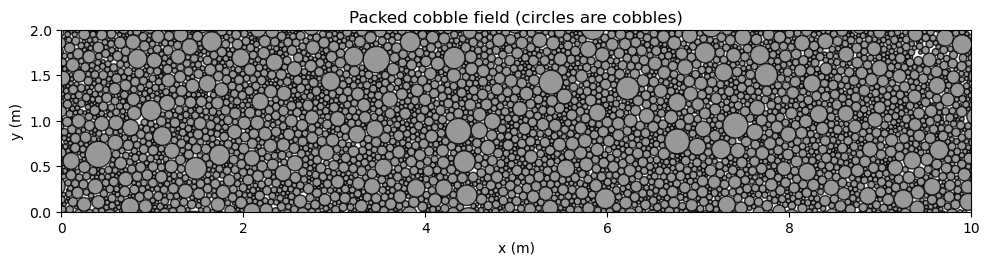

In [42]:
fig, ax = plt.subplots(figsize=(10,4))
# ax.set_xlim(0-1, Lx+1)
# ax.set_ylim(0-1, Ly+1)
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)
ax.set_aspect('equal')
for (cx, cy), rad in zip(centers, R):
    circ = plt.Circle((cx, cy), rad, facecolor='tab:gray', edgecolor='k', alpha=0.8)
    ax.add_patch(circ)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Packed cobble field (circles are cobbles)")
plt.tight_layout()

Computed percentiles:
D10 = 0.0338 m
D15 = 0.0380 m
D50 = 0.0621 m
D85 = 0.1027 m
D90 = 0.1155 m


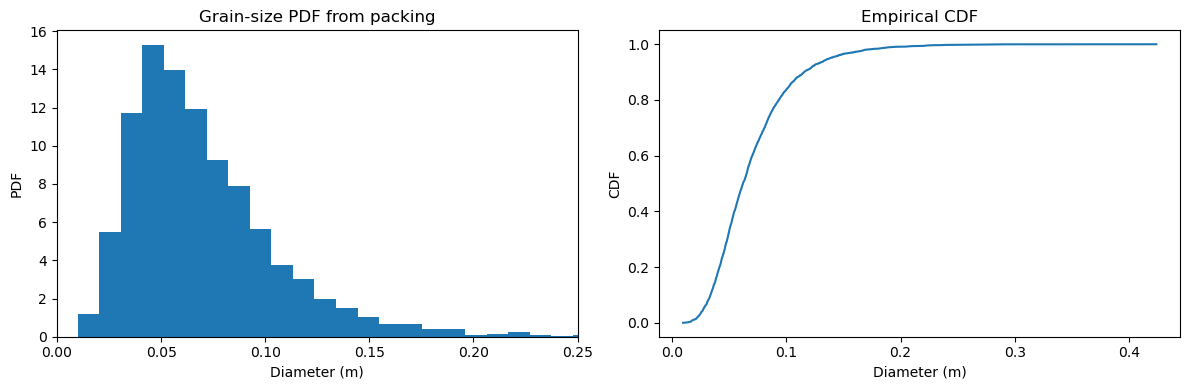

In [3]:

# ---- Load cobble packing results ----
df = pd.read_csv("cobble_packing.csv")   # must contain a column "diameter_m"
diam = df["diameter_m"].values

# ---- Compute grain-size percentiles ----
percentiles = [10, 15, 50, 85, 90]
p_values = np.percentile(diam, percentiles)

print("Computed percentiles:")
for p, val in zip(percentiles, p_values):
    print(f"D{p} = {val:.4f} m")

# ---- Plot histogram and CDF ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + PDF
ax[0].hist(diam, bins=40, density=True)
ax[0].set_xlabel("Diameter (m)")
ax[0].set_ylabel("PDF")
ax[0].set_title("Grain-size PDF from packing")
ax[0].set_xlim(0,0.25)

# Empirical CDF
sorted_d = np.sort(diam)
cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
ax[1].plot(sorted_d, cdf)
ax[1].set_xlabel("Diameter (m)")
ax[1].set_ylabel("CDF")
ax[1].set_title("Empirical CDF")

plt.tight_layout()
plt.show()

In [4]:
from tqdm import tqdm
# ---- load cobble packing results ----
x_c = df["x"].values
y_c = df["y"].values
# z_c = df["z_center"].values
z_c = np.zeros_like(x_c)  # set z=0 for all cobbles
r = 0.5 * df["diameter_m"].values

# ---- define the mesh domain ----
# You can hard-code the domain or derive from max/min cobble positions
dx = 0.01
dy = 0.01

# xmin, xmax = x_c.min()-0.1, x_c.max()+0.1
# ymin, ymax = y_c.min()-0.1, y_c.max()+0.1
xmin = 0-0.1
xmax = Lx+0.1
ymin = 0-0.1
ymax = Ly+0.1

x_grid = np.arange(xmin, xmax+dx, dx)
y_grid = np.arange(ymin, ymax+dy, dy)

nx = len(x_grid)
ny = len(y_grid)

print(f"Grid size: {nx} x {ny}")

# ---- allocate elevation array ----
Z = np.full((ny, nx), -np.inf)

# ---- compute surface elevation ----
for j, y in enumerate(tqdm(y_grid, desc="Rows")):
    for i, x in enumerate(x_grid):

        # distance squared from point to each cobble center
        dx2 = (x - x_c)**2
        dy2 = (y - y_c)**2
        dist2 = dx2 + dy2

        # cobbles that cover this (x,y)
        mask = dist2 <= r*r
        if not np.any(mask):
            continue

        # compute spherical surface only for contributing cobbles
        z_local = z_c[mask] + np.sqrt(r[mask]**2 - dist2[mask])
        Z[j, i] = np.max(z_local)

Z[Z == -np.inf] = 0.0  # set no-cobble areas to z=0

# ---- export to NetCDF ----
ds = xr.Dataset(
    {"z": (("y","x"), Z)},
    coords={"x": x_grid, "y": y_grid},
    attrs={"description": "Cobbles-as-spheres surface elevation at 1 cm resolution"}
)
# ds.to_netcdf("cobble_surface_1cm.nc")


Grid size: 1021 x 221


Rows: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 221/221 [00:02<00:00, 85.45it/s]


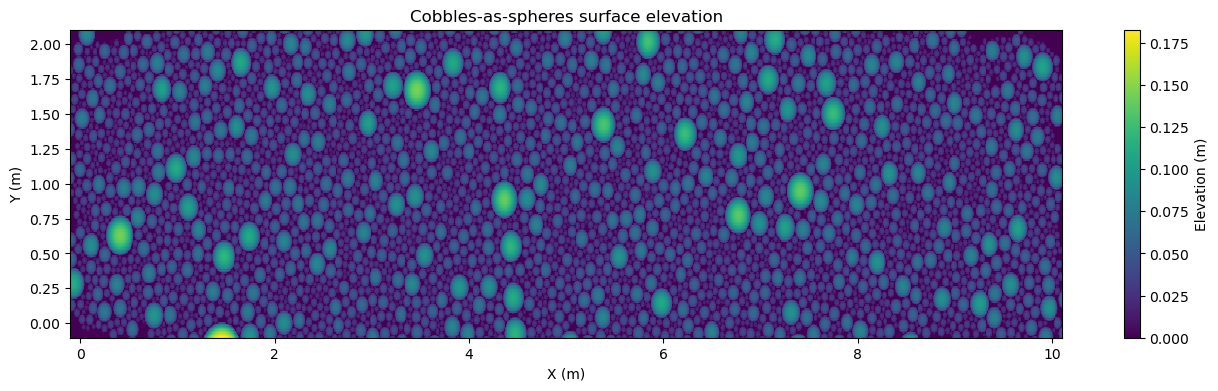

Text(0.5, 1.0, 'Elevation profile at y-index 110')

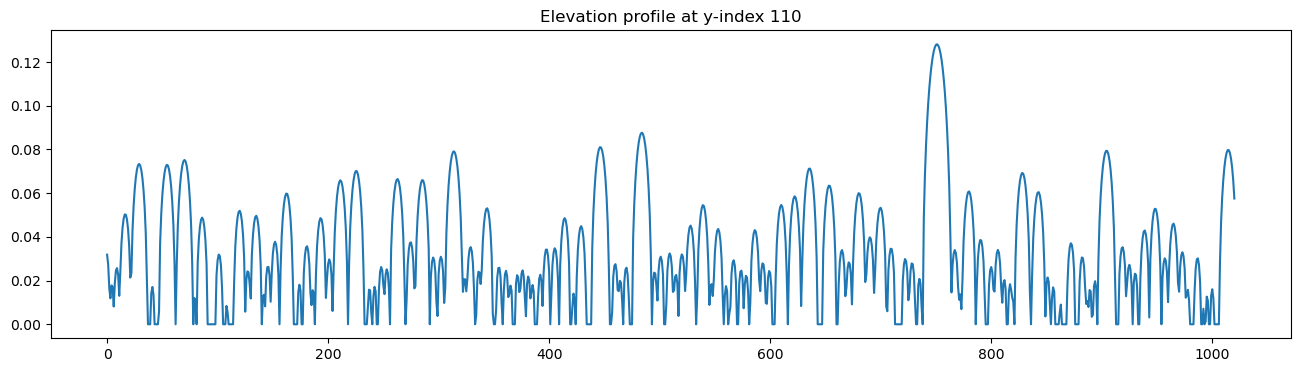

In [26]:
plt.figure(figsize=(16, 4))
plt.pcolormesh(x_grid, y_grid, Z, shading='auto')
plt.colorbar(label="Elevation (m)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
# plt.xlim(0, Lx)
# plt.ylim(0, Ly)
plt.title("Cobbles-as-spheres surface elevation")
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(Z[110, :])
plt.title("Elevation profile at y-index 110")

In [5]:
# create Zs that linearly increases along axis 0 for indices 0..100, then equals Z from 101 onward
n_rows = Z.shape[1]
end_idx = 100  # fade up through index 0..100 (inclusive)

fac=1.0 # factor r representing the shape (1.0 - sphere)

if n_rows <= end_idx:
    # if Z has fewer rows than the fade length, just scale entire array
    factors = np.linspace(0.0, 1.0, n_rows)[:, np.newaxis]
    Zs = Z * factors
else:
    fade_len = end_idx + 1  # number of rows in the fade (0..100 inclusive)
    # factors = np.linspace(0.0, 1.0, fade_len)[np.newaxis, :]  # shape (1, fade_len)
    factors = np.linspace(0.0, fac, fade_len)[np.newaxis, :]  # shape (1, fade_len)
    Zs = np.empty_like(Z)
    Zs[:,:fade_len] = Z[:,:fade_len] * factors
    Zs[:,fade_len:] = Z[:,fade_len:] * fac

# sanity checks
print("Zs shape:", Zs.shape)
print("First row (should be zeros or very small):", np.unique(Zs[0])[:5])
print("Row 100 matches original scaled by 1:", np.allclose(Zs[100], Z[100]) if n_rows>100 else "n/a")
print("Rows from 101 onward equal Z (if present):", np.allclose(Zs[101:], Z[101:]) if n_rows>101 else "n/a")

Zs shape: (221, 1021)
First row (should be zeros or very small): [0.         0.00172776 0.00207742 0.00237496 0.00249288]
Row 100 matches original scaled by 1: False
Rows from 101 onward equal Z (if present): False


In [6]:
## add additional slope with 1/5 gradient x-direction
Zs += (x_grid[np.newaxis, :] / 5.0) 

Zs = Zs +1.4

In [10]:
## add
# 
Z0 = np.zeros((201, 1550))
Z1 = np.zeros((201, 5600))

Z1 += (np.arange(5600)[np.newaxis, :] *0.025/100) # 1/4 slope in x-direction, the smaller slope

Z_total = np.concatenate((Z0, Z1, Zs[10:-10, 10:-10  ]), axis=1)


# file_cobble = "cobble_surface_with_slope_v2.txt"
file_cobble = f"cobble_surface_with_slope_v9_res001_sec8_fac{fac}.txt"
## write to txt file, each row is a line
np.savetxt(file_cobble, Z_total)

## add header line for gpusph 
with open(file_cobble, "r+") as f:
    content = f.read()
    f.seek(0, 0)
    f.write(f"north: 2.005 \nsouth: -0.005\neast: 81.505\nwest: -0.005\nrows: {Z_total.shape[0]}\ncols: {Z_total.shape[1]}\n" + content)

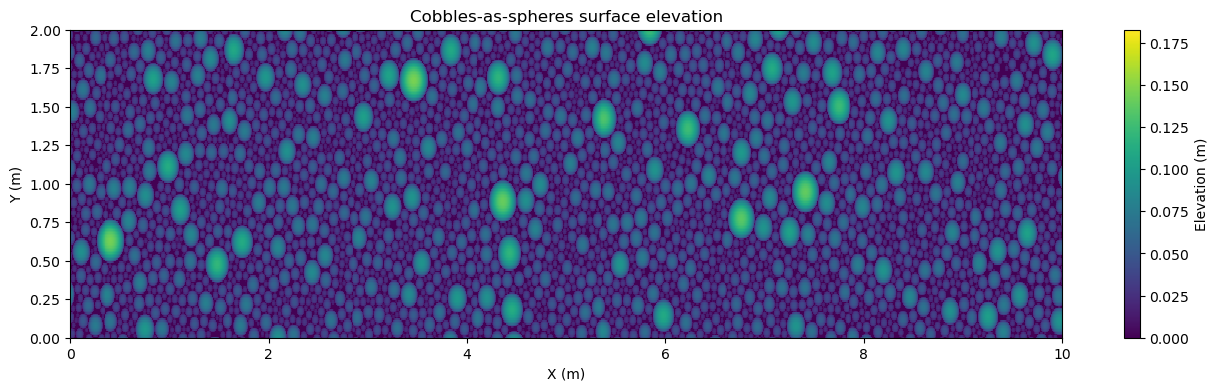

Text(0.5, 1.0, 'Elevation profile at y-index 110')

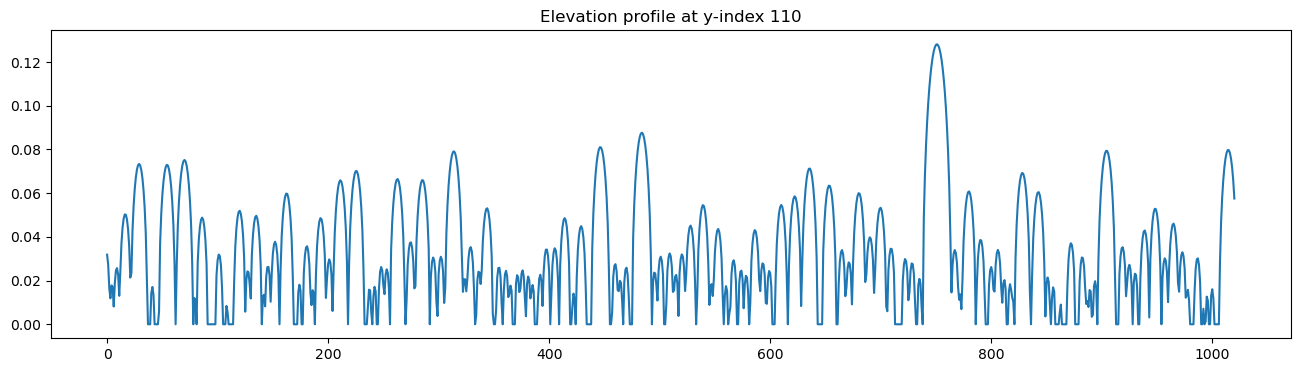

In [49]:
plt.figure(figsize=(16, 4))
plt.pcolormesh(x_grid, y_grid, Z, shading='auto')
plt.colorbar(label="Elevation (m)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.title("Cobbles-as-spheres surface elevation")
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(Z[110, :])
plt.title("Elevation profile at y-index 110")

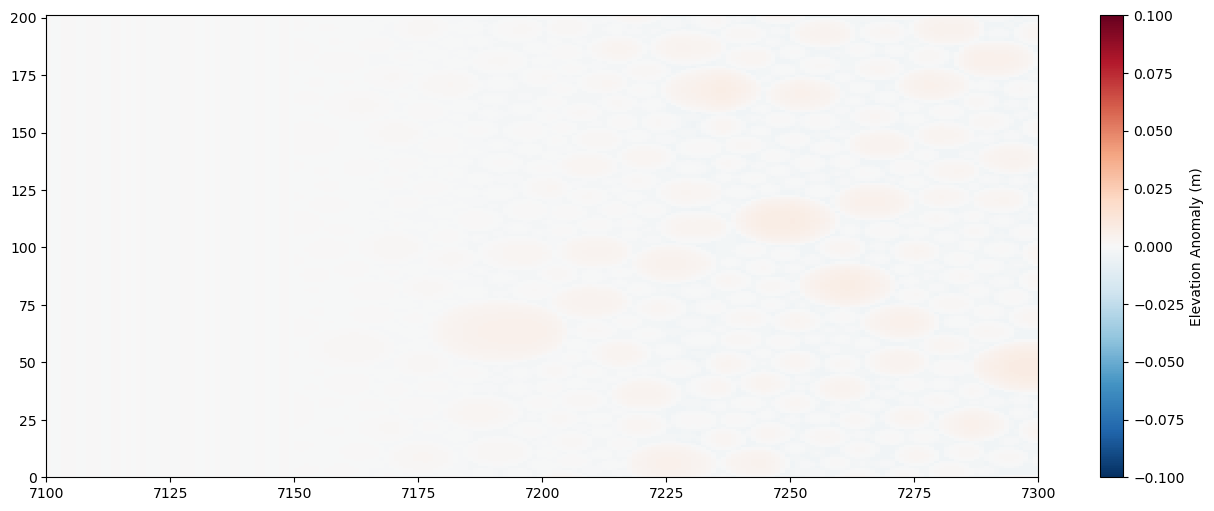

In [50]:
Z_mean = np.mean(Z_total,axis=0)
Z_anomaly = Z_total - Z_mean[np.newaxis, :]

plt.figure(figsize=(16, 6))
plt.pcolormesh(Z_anomaly, shading='auto',cmap='RdBu_r',vmax=0.1, vmin=-0.1)
plt.xlim(7100,7300)
plt.colorbar(label="Elevation Anomaly (m)")

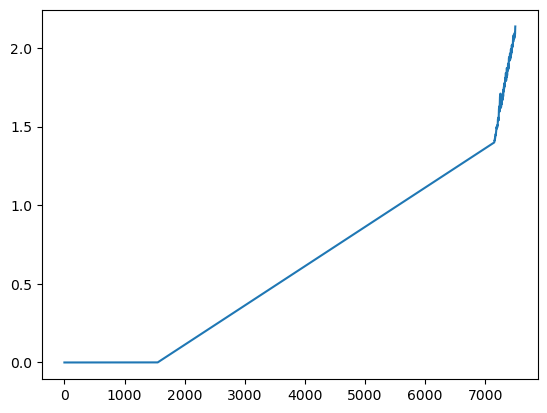

In [12]:
plt.plot(Z_total[110, 0:7500])

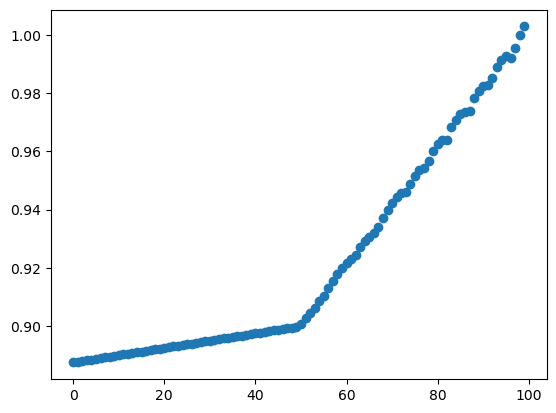

In [150]:
plt.plot(Z_total[110, 7100:7200],'o')

In [37]:
# check the txt file: cobble_surface_with_slope_v3.txt
with open("cobble_surface_with_slope_v7_res001_sec8.txt", "r") as f:
    lines = f.readlines()
    header = lines[:6]
    data_lines = lines[6:]
    print("Header:")
    for line in header:
        print(line.strip())
    print("First 5 data lines:")
    for line in data_lines[:5]:
        print(line.strip())

# load the txt file back to verify
Z_loaded = np.loadtxt("cobble_surface_with_slope_v7_res001_sec8.txt", skiprows=6)
print("Loaded Z shape:", Z_loaded.shape)

Header:
north: 2.005
south: -0.005
east: 81.505
west: -0.005
rows: 201
cols: 8151
First 5 data lines:
0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+00 0.000000000000000000e+0

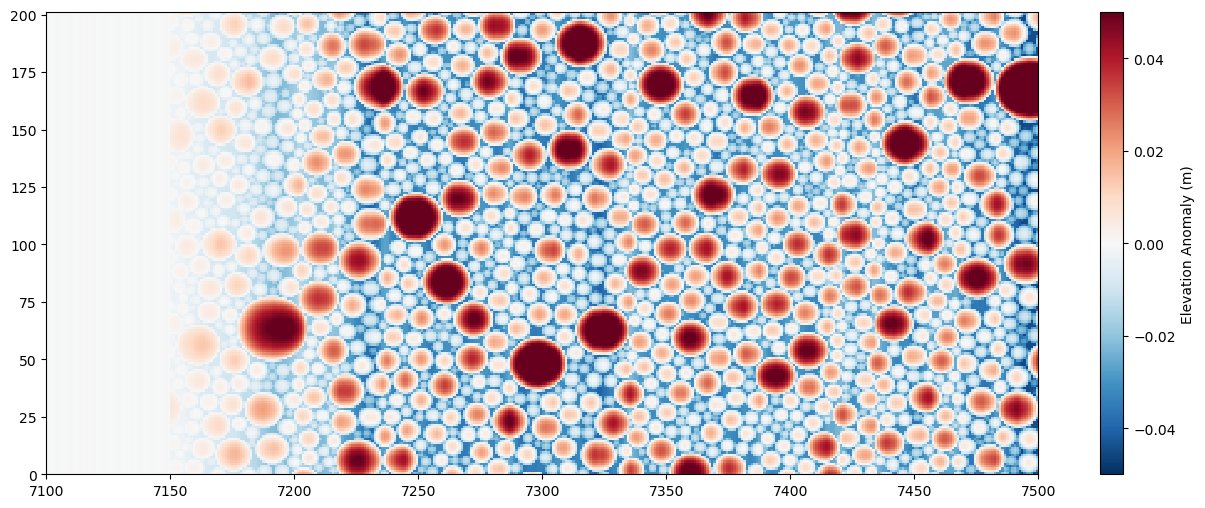

In [38]:
Z_mean = np.mean(Z_loaded,axis=0)
Z_anomaly = Z_loaded - Z_mean[np.newaxis, :]

plt.figure(figsize=(16, 6))
plt.pcolormesh(Z_anomaly, shading='auto',cmap='RdBu_r',vmax=0.05, vmin=-0.05)
plt.xlim(7100,7500)
plt.colorbar(label="Elevation Anomaly (m)")